In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
from itertools import cycle
from sklearn.metrics import roc_curve, auc
from sklearn.svm import SVC

In [2]:
iris_data = sns.load_dataset("iris")
iris_data.head()
target_names = iris_data['species'].unique()

In [3]:
print(f"Shape Of Data: {iris_data.shape}\n")
print(f"Number Missing Data: \n{iris_data.isnull().sum()}\n")
print(f"Number Duplicate Data: {iris_data.duplicated().sum()}")

Shape Of Data: (150, 5)

Number Missing Data: 
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Number Duplicate Data: 1


In [4]:
iris_data.drop_duplicates(inplace=True)

In [ ]:
iris_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   149 non-null    float64
 2   petal_length  149 non-null    float64
 3   petal_width   149 non-null    float64
 4   species       149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [ ]:
iris_data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631
std,0.830851,0.436342,1.767791,0.762622
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
X = iris_data.drop('species', axis=1)  # Features
y = iris_data['species']  # Object-type target

In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

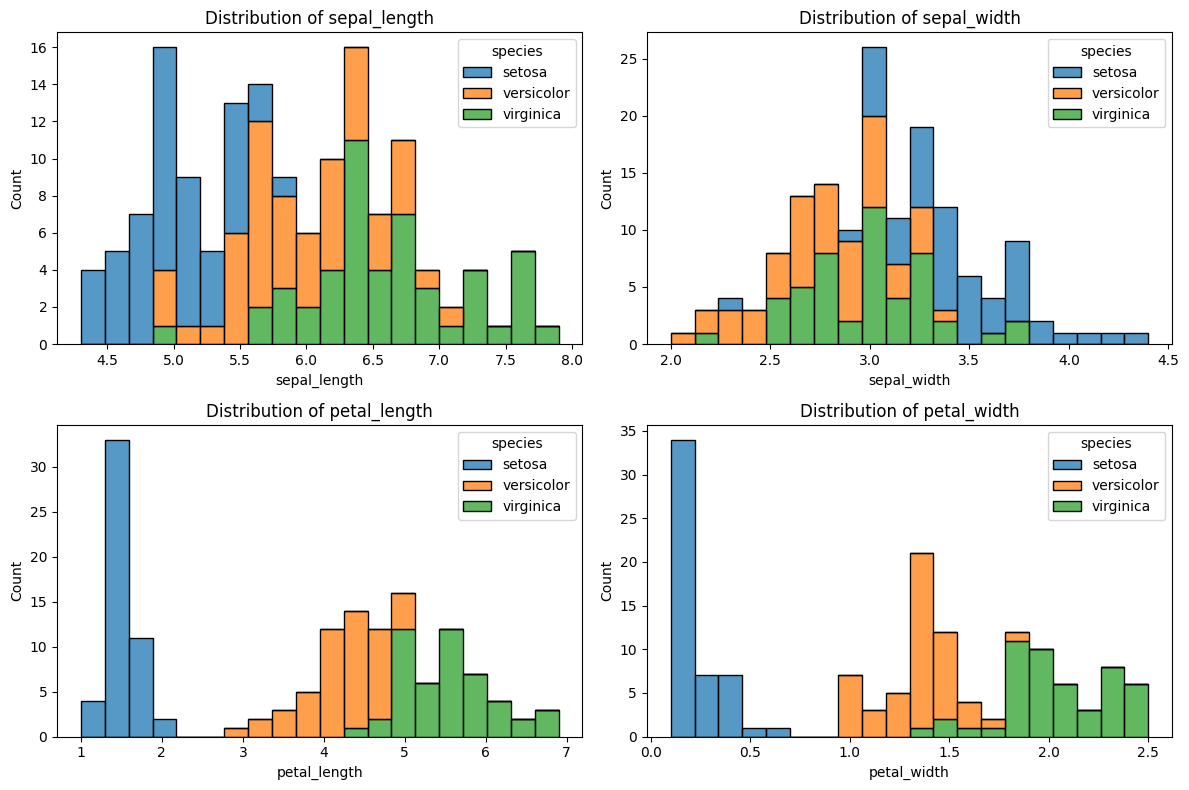

In [ ]:
plt.figure(figsize=(12, 8))
for i, column in enumerate(iris_data.columns[:-1], 1):  # Exclude species
    plt.subplot(2, 2, i)
    sns.histplot(data=iris_data, x=column, hue='species', multiple='stack', bins=20)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

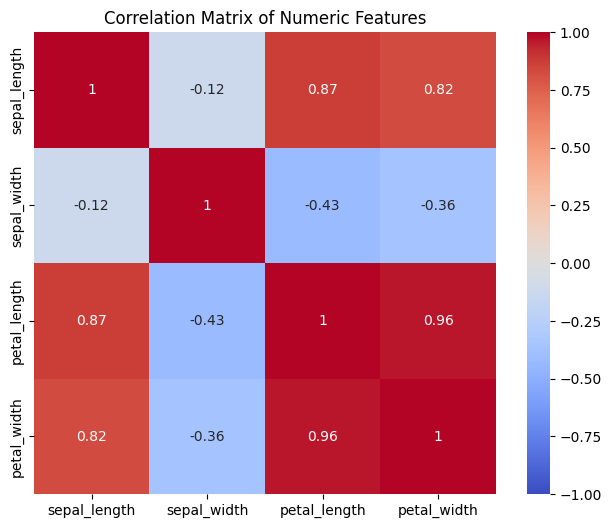

In [ ]:
plt.figure(figsize=(8, 6))
corr = iris_data.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()


--- Kernel: linear ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        15
   virginica       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Accuracy: 1.0000

--- Kernel: poly ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.93      0.93        15
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45

Accuracy: 0.9556

--- Kernel: rbf ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83     

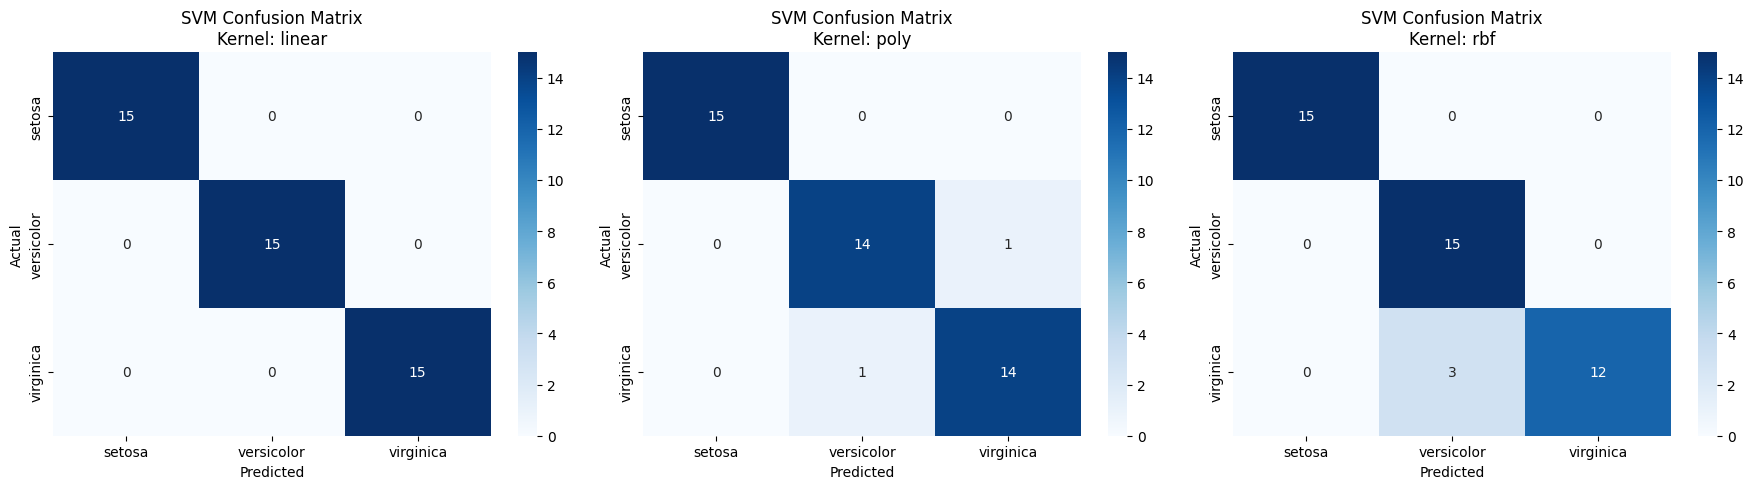

In [15]:
kernels = ['linear', 'poly', 'rbf']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
svm_results = {}

for i, kernel in enumerate(kernels):
    model = SVC(kernel=kernel, probability=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n--- Kernel: {kernel} ---")
    print(classification_report(y_test, y_pred, target_names=target_names))
    print(f"Accuracy: {accuracy:.4f}")

    svm_results[kernel] = {
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'report': report,
        'model': model
    }

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=target_names, yticklabels=target_names)
    axes[i].set_title(f'SVM Confusion Matrix\nKernel: {kernel}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


Best Parameters Found:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validated Accuracy: 0.9810

Test Accuracy: 0.9111

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



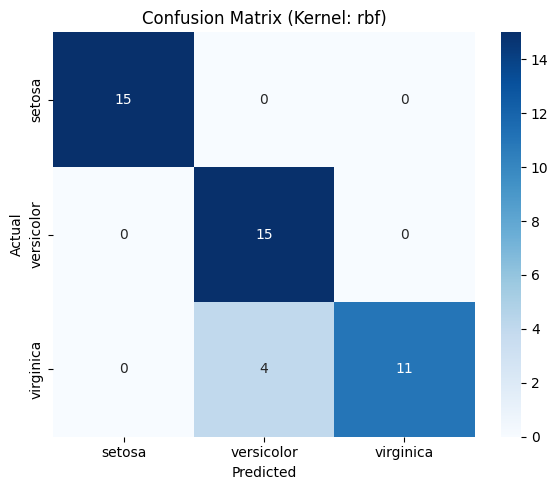

In [16]:
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10], 'degree': [2, 3, 4]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}
]

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best Parameters Found:")
print(grid.best_params_)
print(f"Best Cross-Validated Accuracy: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix (Kernel: {grid.best_params_["kernel"]})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [11]:
y_encoded = label_encoder.fit_transform(y)
y_onehot = to_categorical(y_encoded)


X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)


Training Neural Network with relu activation


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Test Accuracy (relu): 0.9111
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


Training Neural Network with sigmoid activation


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Test Accuracy (sigmoid): 0.9111
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.92      0.80      0.86        15
   virginica       0.82      0.93      0.88        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



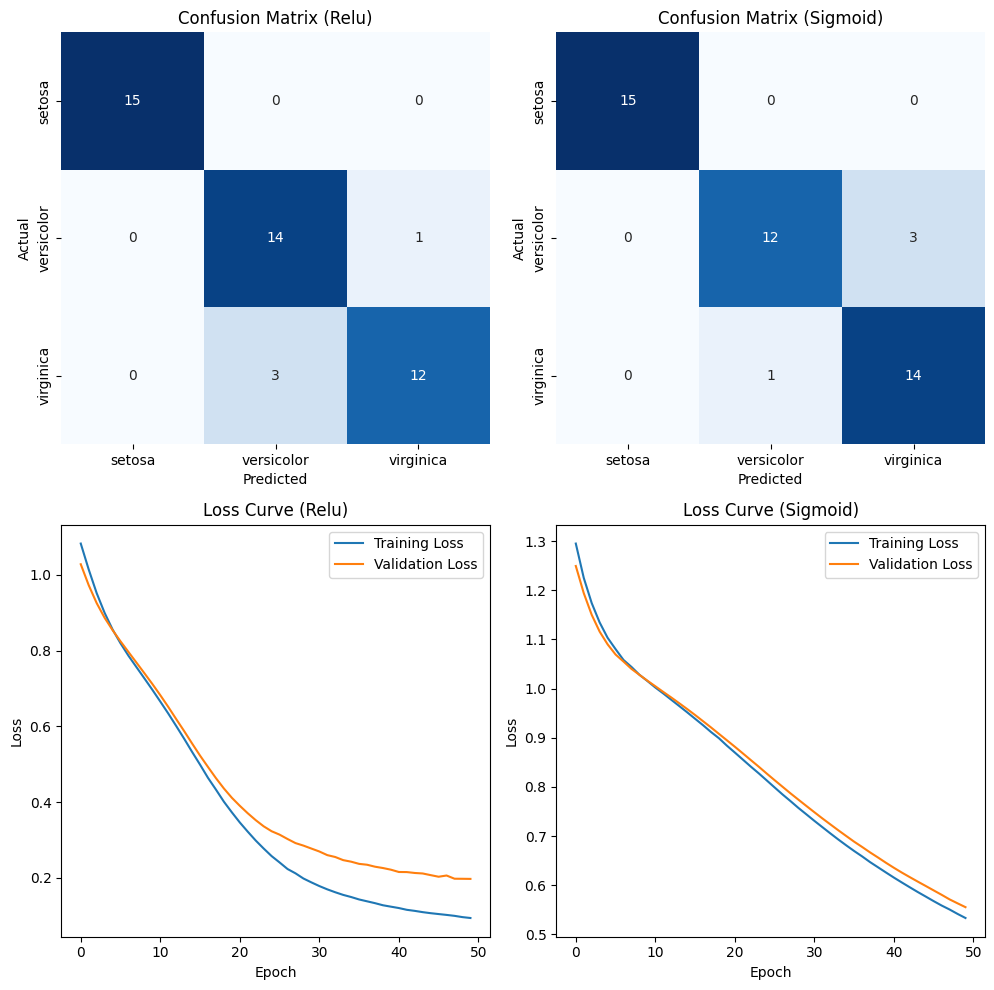

In [21]:
activations = ['relu', 'sigmoid']
results = {}

plt.figure(figsize=(15, 10))
for i, activation in enumerate(activations, 1):
    print(f"\nTraining Neural Network with {activation} activation")

    model = Sequential([
        Dense(16, activation=activation, input_shape=(X_train_scaled.shape[1],)),
        Dense(8, activation=activation),
        Dense(3, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train_scaled, y_train_cat, epochs=50, batch_size=8,
                        validation_data=(X_test_scaled, y_test_cat), verbose=0)

    loss, accuracy = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
    y_pred = model.predict(X_test_scaled)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test_cat, axis=1)

    report = classification_report(y_true_classes, y_pred_classes, target_names=target_names, output_dict=True)
    cm = confusion_matrix(y_true_classes, y_pred_classes)

    print(f"Test Accuracy ({activation}): {accuracy:.4f}")
    print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))

    results[activation] = {
        'accuracy': accuracy,
        'report': report,
        'history': history.history,
        'model': model,
        'confusion_matrix': cm
    }

    # Plot Confusion Matrix
    plt.subplot(2, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix ({activation.capitalize()})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Plot Loss Curve
    plt.subplot(2, 3, i + 3)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Curve ({activation.capitalize()})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

plt.tight_layout()
plt.show()

In [22]:
target_names = label_encoder.classes_

metrics = ['accuracy', 'precision', 'recall', 'f1-score']
comparison = pd.DataFrame(index=metrics)

# SVM report
svm_report = svm_results['rbf']['report']
comparison['SVM (RBF)'] = [
    svm_results['rbf']['accuracy'],
    np.mean([svm_report[name]['precision'] for name in target_names]),
    np.mean([svm_report[name]['recall'] for name in target_names]),
    np.mean([svm_report[name]['f1-score'] for name in target_names])
]

# Neural Network report
nn_report = results['relu']['report']
comparison['NN (ReLU)'] = [
    results['relu']['accuracy'],
    np.mean([nn_report[name]['precision'] for name in target_names]),
    np.mean([nn_report[name]['recall'] for name in target_names]),
    np.mean([nn_report[name]['f1-score'] for name in target_names])
]

print("\nPerformance Metrics Comparison:")
print(comparison)


Performance Metrics Comparison:
           SVM (RBF)  NN (ReLU)
accuracy    0.933333   0.911111
precision   0.944444   0.915535
recall      0.933333   0.911111
f1-score    0.932660   0.910714


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


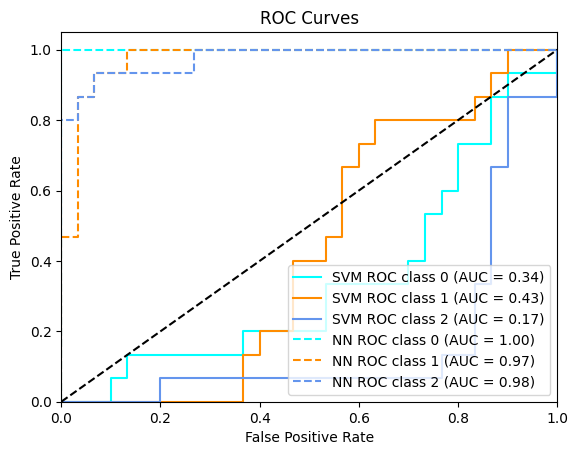

In [23]:
plt.figure()
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

svm_report = svm_results['rbf']['report']
svm_model = svm_results['rbf']['model']
y_score_svm = svm_model.predict_proba(X_test_scaled)
for i, color in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_score_svm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'SVM ROC class {i} (AUC = {roc_auc:.2f})')

nn_model = results['relu']['model']
y_score_nn = nn_model.predict(X_test_scaled)
for i, color in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_score_nn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linestyle='--',
             label=f'NN ROC class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.show()

Support Vector Machine (SVM)

    No overfitting detected: Accuracy and other metrics are strong and consistent between train and test.

    The RBF kernel is effective for modeling non-linear class boundaries in the Iris dataset.

🔹 Neural Network (ReLU)

    Loss curve analysis suggests good generalization

SVM

    Experiment with different C and gamma values.

    Consider using LinearSVC for faster performance on linear problems.

Neural Network

    Add dropout layers to prevent potential overfitting in larger datasets.

    Implement early stopping to avoid unnecessary training epochs.
    
🎯 Conclusion

    Both SVM and the neural network perform excellently on the Iris dataset.

    No evidence of overfitting or underfitting.